In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0   733k      0 --:--:--  0:20:28 --:--:--  817k


In [2]:
!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [3]:
!gunzip SUSY.csv.gz

In [4]:
!wc -l SUSY.csv

 5000000 SUSY.csv


In [5]:
!head -500000 SUSY.csv > SUSY-small.csv

In [6]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

VarNames = ["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta",
            "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R",
            "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames = ["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))


filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

df_sig = df[df["signal"] == 1]
df_bkg = df[df["signal"] == 0]

In [8]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


In [9]:
# checking for missing values & getting a statistical summary 
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   signal        500000 non-null  float64
 1   l_1_pT        500000 non-null  float64
 2   l_1_eta       500000 non-null  float64
 3   l_1_phi       500000 non-null  float64
 4   l_2_pT        500000 non-null  float64
 5   l_2_eta       500000 non-null  float64
 6   l_2_phi       500000 non-null  float64
 7   MET           500000 non-null  float64
 8   MET_phi       500000 non-null  float64
 9   MET_rel       500000 non-null  float64
 10  axial_MET     500000 non-null  float64
 11  M_R           500000 non-null  float64
 12  M_TR_2        500000 non-null  float64
 13  R             500000 non-null  float64
 14  MT2           500000 non-null  float64
 15  S_R           500000 non-null  float64
 16  M_Delta_R     500000 non-null  float64
 17  dPhi_r_b      500000 non-null  float64
 18  cos_

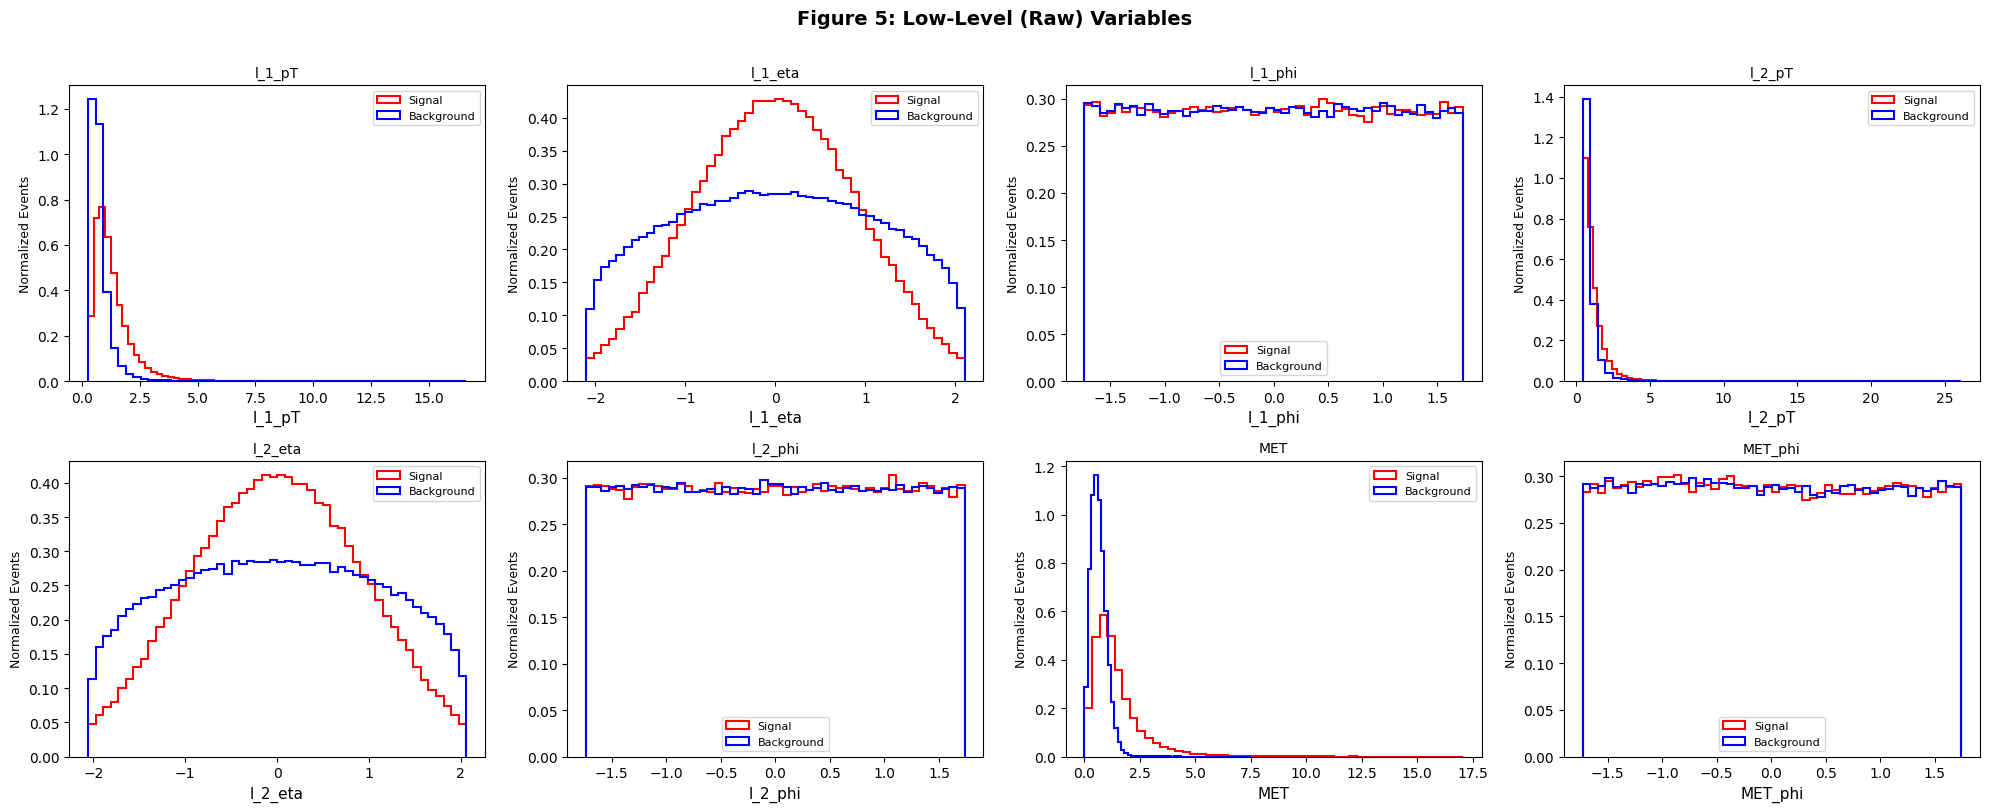

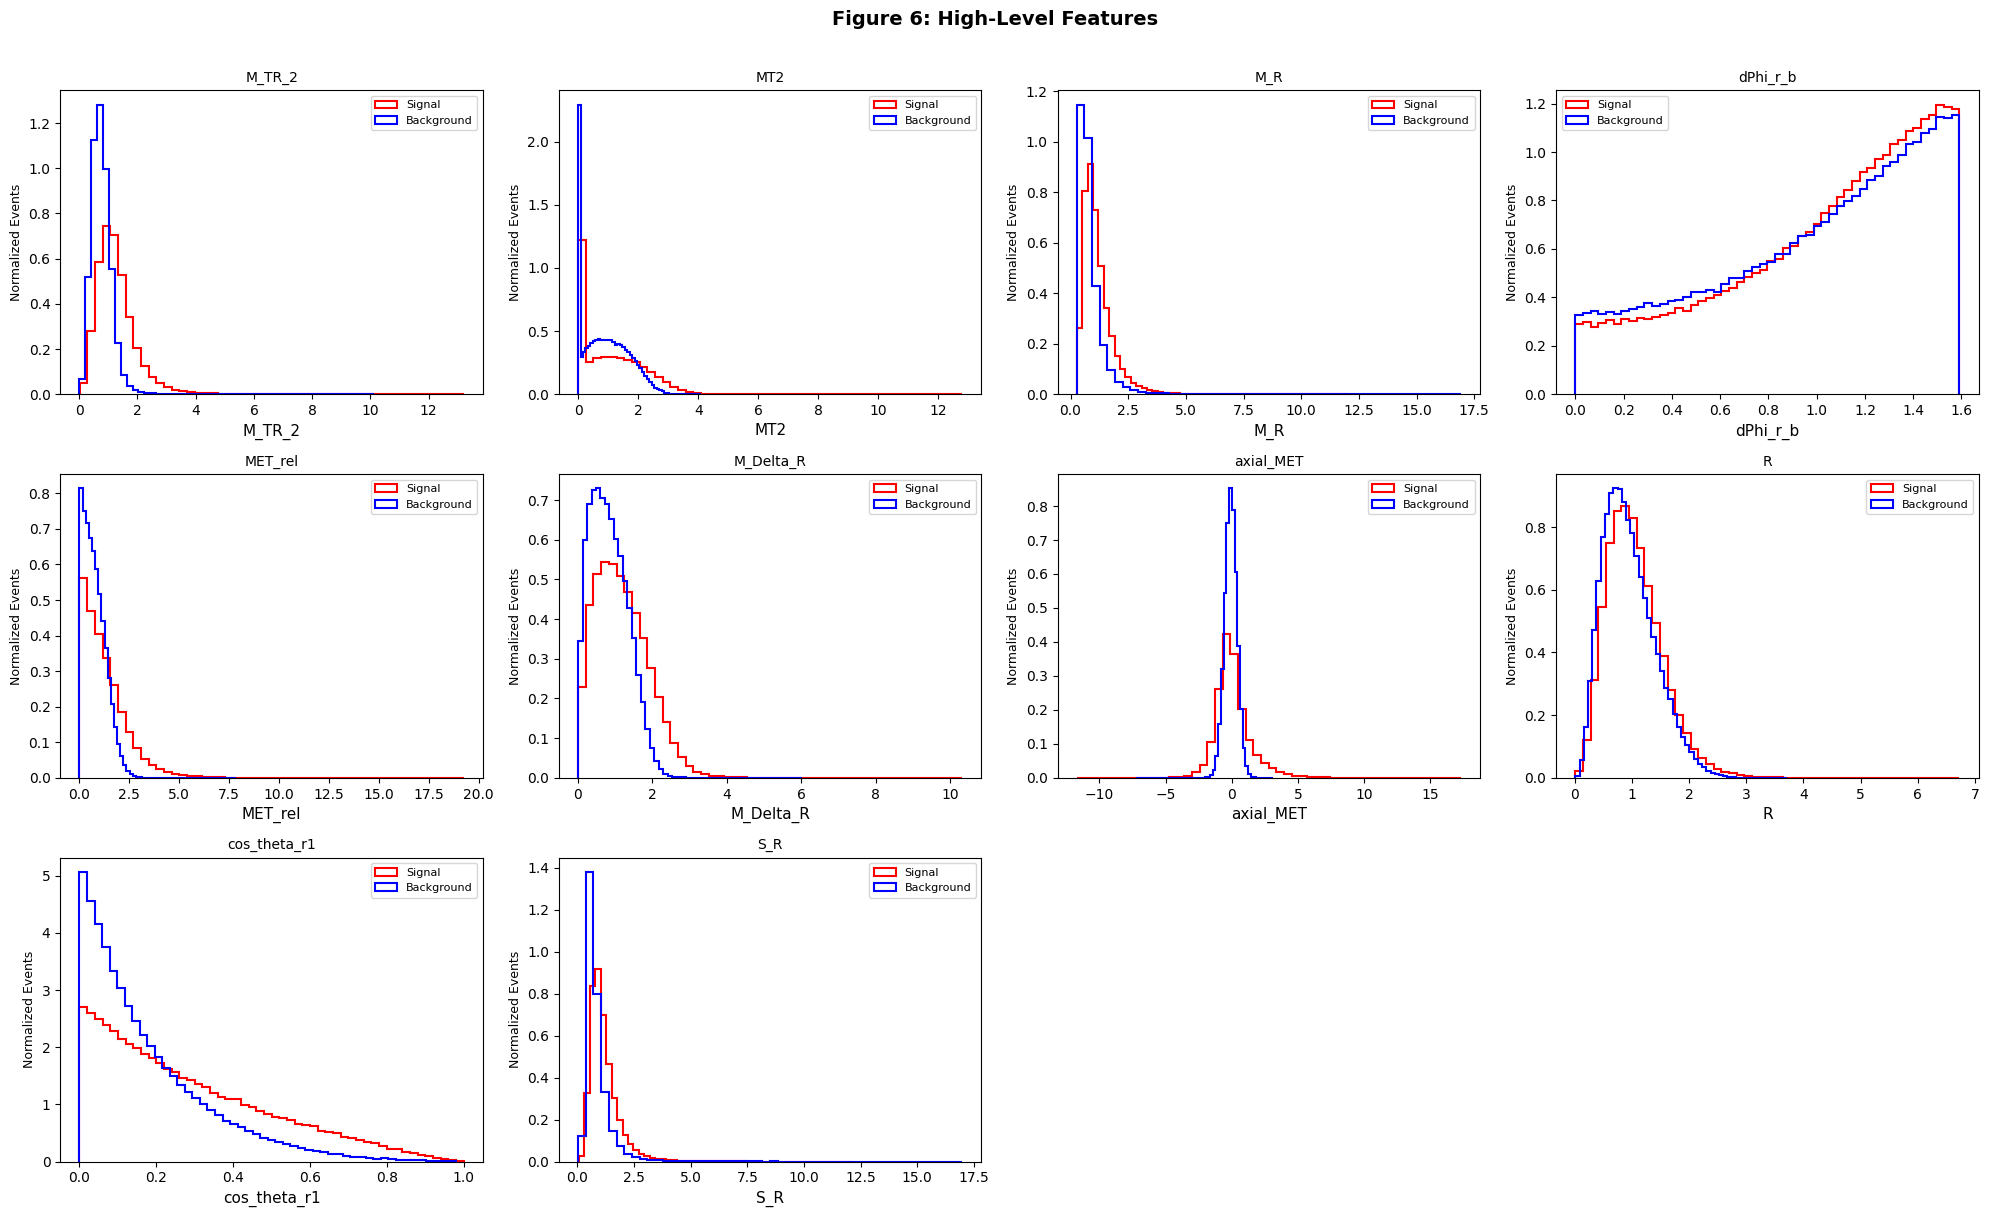

In [10]:
# Exercise 3

def plot_feature_grid(var_list, df_sig, df_bkg, title, ncols=4):
    """
    Plot signal vs background distributions in a grid of subplots.
    Reproduces figures 5 & 6 from the paper.
    """
    nrows = int(np.ceil(len(var_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(var_list):
        ax = axes[i]
        ax.hist(df_sig[var], bins=50, density=True, histtype='step', color='red', linewidth=1.5, label='Signal')
        ax.hist(df_bkg[var], bins=50, density=True, histtype='step', color='blue', linewidth=1.5, label='Background')
        
        ax.set_xlabel(var, fontsize=11)
        ax.set_ylabel('Normalized Events', fontsize=9)
        ax.legend(fontsize=8)
        ax.set_title(var, fontsize=10)

    # hiding any unused subplot panels
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# figure 5: Raw kinematic variables
plot_feature_grid(RawNames, df_sig, df_bkg, title="Figure 5: Low-Level (Raw) Variables")

# figure 6: High-level engineered features
plot_feature_grid(FeatureNames, df_sig, df_bkg, title="Figure 6: High-Level Features")

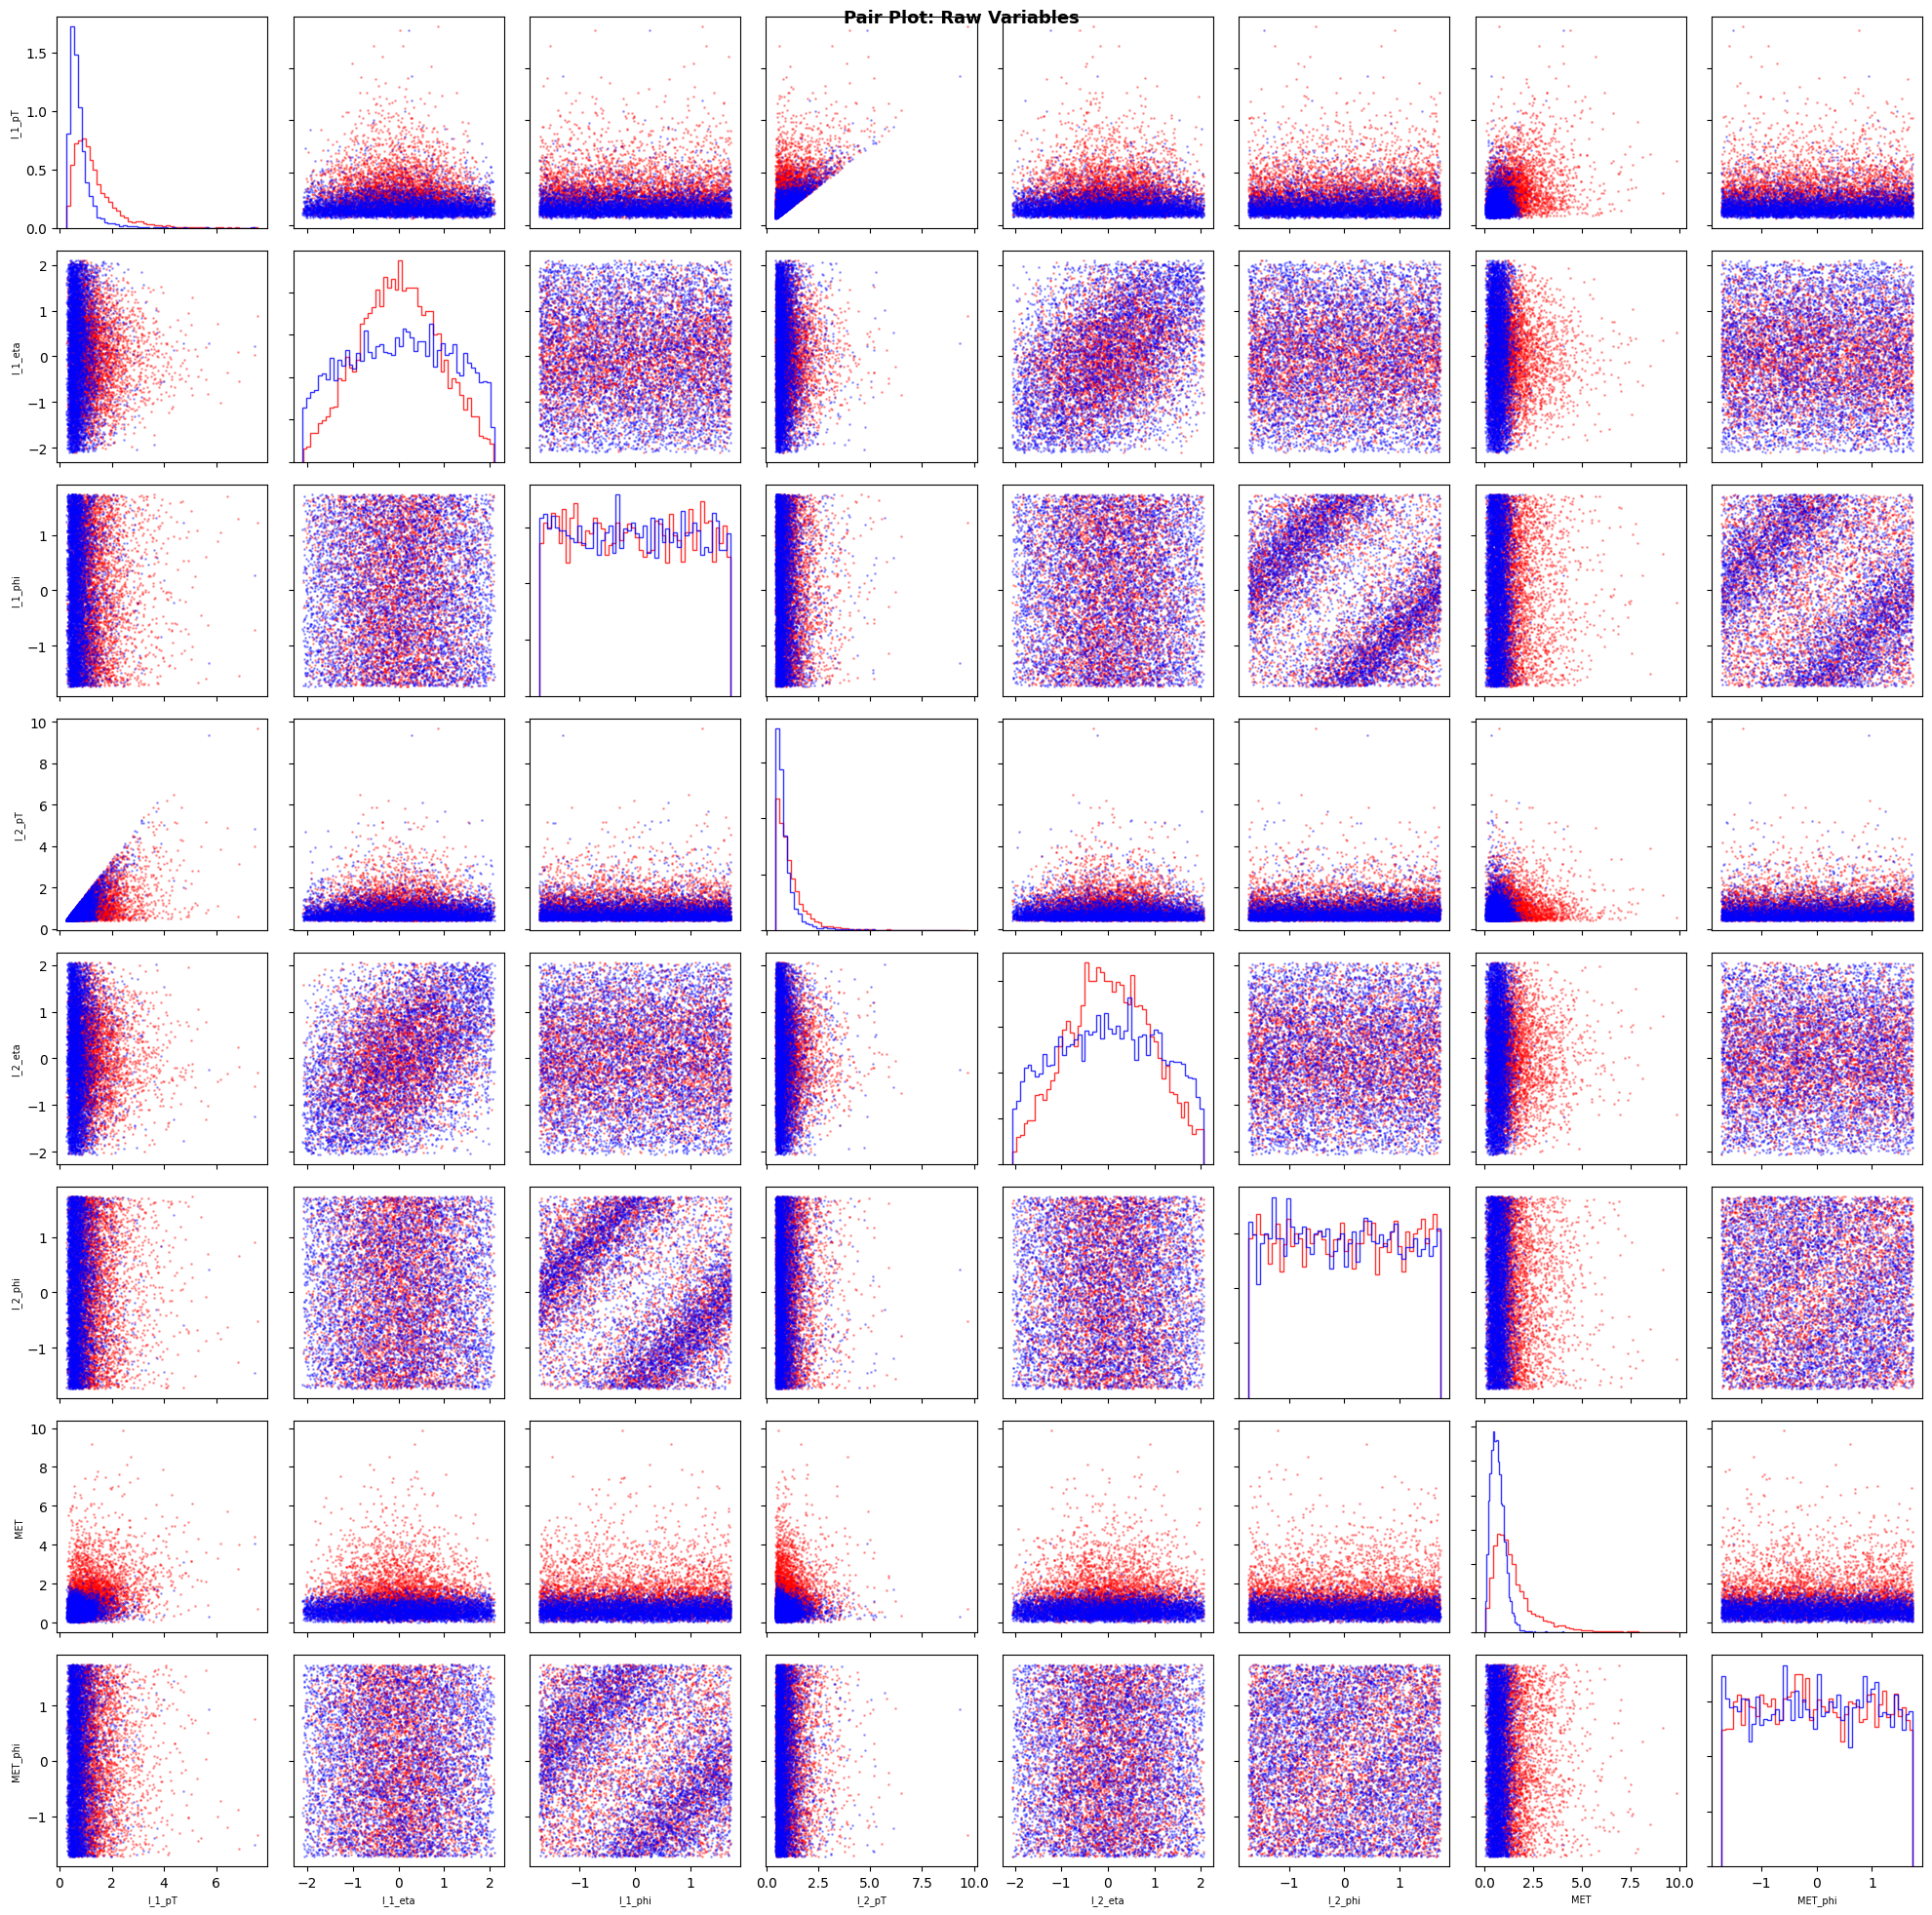

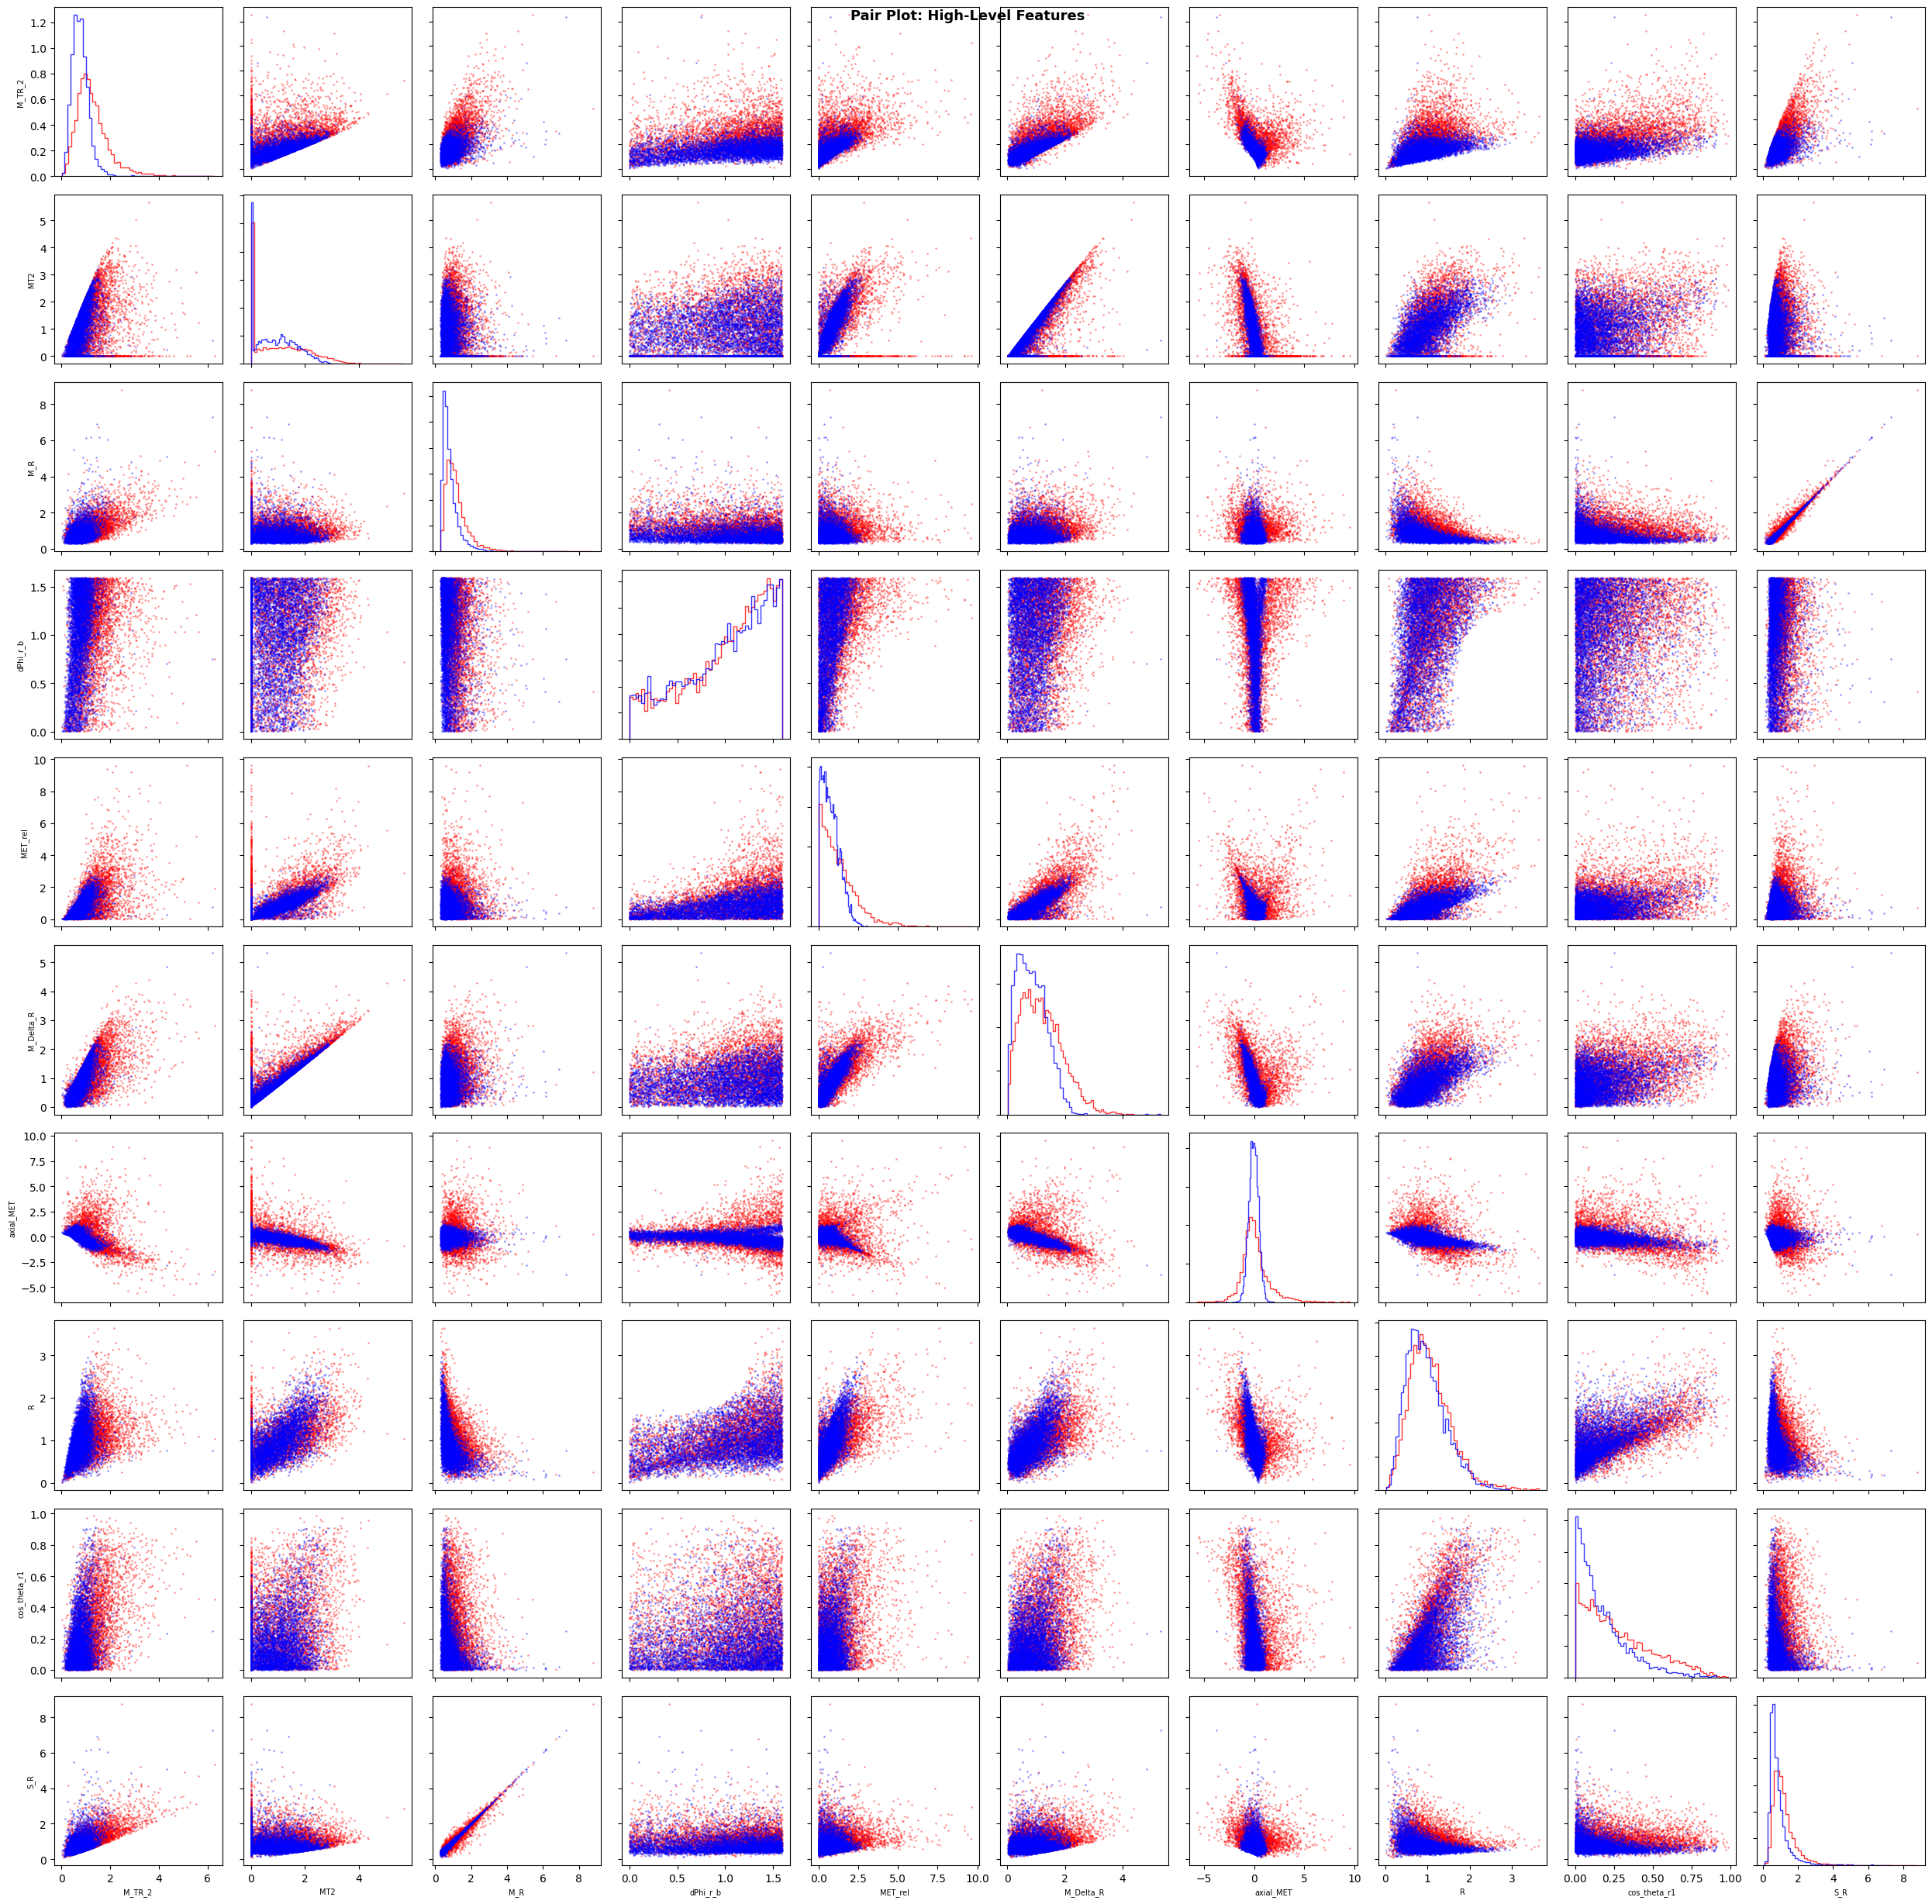

In [11]:
# Exercise 4 

def pair_plot(df_sig, df_bkg, var_list, title="Pair Plot", n_bins=50, subsample=5000):
    """
    Create a pair plot grid comparing signal vs background.
    subsample: use a random subset for speed.
    """
    # Subsample for speed (Part b optimization)
    sig_sub = df_sig[var_list].sample(n=min(subsample, len(df_sig)), random_state=42)
    bkg_sub = df_bkg[var_list].sample(n=min(subsample, len(df_bkg)), random_state=42)

    n = len(var_list)
    fig, axes = plt.subplots(n, n, figsize=(2.5 * n, 2.5 * n))

    for i, var_y in enumerate(var_list):
        for j, var_x in enumerate(var_list):
            ax = axes[i][j]
            if i == j:
                # Diagonal: 1D histogram
                ax.hist(sig_sub[var_x], bins=n_bins, density=True,
                        histtype='step', color='red', alpha=0.8)
                ax.hist(bkg_sub[var_x], bins=n_bins, density=True,
                        histtype='step', color='blue', alpha=0.8)
            else:
                # Off-diagonal: 2D scatter
                ax.scatter(sig_sub[var_x], sig_sub[var_y],
                           s=1, alpha=0.3, color='red', label='Signal')
                ax.scatter(bkg_sub[var_x], bkg_sub[var_y],
                           s=1, alpha=0.3, color='blue', label='Background')

            if i == n - 1:
                ax.set_xlabel(var_x, fontsize=7)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(var_y, fontsize=7)
            else:
                ax.set_yticklabels([])

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Part a: Low-level features
pair_plot(df_sig, df_bkg, RawNames, title="Pair Plot: Raw Variables")

# Part a: High-level features
pair_plot(df_sig, df_bkg, FeatureNames, title="Pair Plot: High-Level Features")

part c:

In [12]:
!pip install tabulate
!pip install --upgrade pip

In [13]:
# Exercise 4.2
from IPython.display import HTML, display
import tabulate as tab_module

def compute_and_display_matrices(df, var_list, label="All Variables"):
    """
    Part b + c: Compute covariance and correlation matrices and display
    them as formatted tables using tabulate.
    """
    data = df[var_list].values.T  # shape: (n_vars, n_samples)

    cov_matrix  = np.cov(data)
    corr_matrix = np.corrcoef(data)

    def matrix_to_table(matrix, var_list, sig_figs=3):
        """Convert a numpy matrix to a list-of-lists with row labels."""
        rows = []
        for i, row_name in enumerate(var_list):
            row = [row_name] + [f"{v:.{sig_figs}g}" for v in matrix[i]]
            rows.append(row)
        return rows

    headers = [""] + var_list

    print(f"\n=== Covariance Matrix: {label} ===")
    cov_table = matrix_to_table(cov_matrix, var_list)
    display(HTML(tab_module.tabulate(cov_table, tablefmt='html', headers=headers)))

    print(f"\n=== Correlation Matrix: {label} ===")
    corr_table = matrix_to_table(corr_matrix, var_list)
    display(HTML(tab_module.tabulate(corr_table, tablefmt='html', headers=headers)))

    return cov_matrix, corr_matrix

# Part d
cov_all,  corr_all  = compute_and_display_matrices(df, VarNames[1:],   "All Observables")
cov_raw,  corr_raw  = compute_and_display_matrices(df, RawNames,        "Low-Level (Raw) Features")
cov_feat, corr_feat = compute_and_display_matrices(df, FeatureNames,    "High-Level Features")



=== Covariance Matrix: All Observables ===


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0.000397,7.66e-05,0.305,-0.000349,0.000737,0.228,-0.000937,0.0975,-0.00973,0.364,0.287,-0.0597,-0.0124,0.343,0.0977,-0.0469,0.0222
l_1_eta,-0.000397,1,-0.000858,-0.000163,0.408,-0.00104,-0.00215,-0.000589,-0.00137,-0.00111,-0.000554,-0.000669,0.000301,0.000427,-0.000604,-0.000987,-0.00074,0.000322
l_1_phi,7.66e-05,-0.000858,1,0.00131,0.000251,-0.267,0.000766,-0.185,0.000706,-0.00187,0.00106,0.000869,0.000202,0.00106,0.00146,0.000901,0.000994,0.000259
l_2_pT,0.305,-0.000163,0.00131,0.425,-0.000576,0.000156,0.0795,-0.00156,-0.000534,0.0513,0.325,0.163,-0.0994,-0.0689,0.322,0.00572,-0.00383,-0.0279
l_2_eta,-0.000349,0.408,0.000251,-0.000576,1.01,0.000442,0.000382,-0.000322,0.00108,-0.000756,-0.000608,1.89e-05,0.000321,0.0014,-0.000679,0.00067,-0.000307,0.000296
l_2_phi,0.000737,-0.00104,-0.267,0.000156,0.000442,1,-0.000304,-0.0354,0.00145,-0.0018,0.00076,0.000509,0.000551,0.00226,0.000906,0.00133,-0.000241,3.7e-05
MET,0.228,-0.00215,0.000766,0.0795,0.000382,-0.000304,0.762,-0.00279,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.0731
MET_phi,-0.000937,-0.000589,-0.185,-0.00156,-0.000322,-0.0354,-0.00279,1,-0.0049,-0.000442,-0.00148,-0.0012,-0.00023,8.39e-05,-0.00171,-0.00057,-0.00171,0.000119
MET_rel,0.0975,-0.00137,0.000706,-0.000534,0.00108,0.00145,0.546,-0.0049,0.79,-0.12,0.0437,0.302,0.249,0.409,0.0823,0.415,0.146,0.0553
axial_MET,-0.00973,-0.00111,-0.00187,0.0513,-0.000756,-0.0018,0.154,-0.000442,-0.12,1.01,0.0171,-0.185,-0.181,-0.461,-0.0414,-0.233,-0.0251,-0.0537



=== Correlation Matrix: All Observables ===


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.000579,0.000112,0.684,-0.000509,0.00108,0.383,-0.00137,0.16,-0.0142,0.851,0.723,-0.186,-0.0211,0.811,0.229,-0.157,0.165
l_1_eta,-0.000579,1,-0.000854,-0.000249,0.406,-0.00104,-0.00245,-0.000587,-0.00154,-0.0011,-0.000882,-0.00115,0.000639,0.000496,-0.000975,-0.00158,-0.00169,0.00163
l_1_phi,0.000112,-0.000854,1,0.00201,0.000249,-0.266,0.000876,-0.184,0.000793,-0.00186,0.00169,0.00149,0.000427,0.00123,0.00236,0.00144,0.00228,0.00131
l_2_pT,0.684,-0.000249,0.00201,1,-0.00088,0.000239,0.14,-0.00239,-0.000921,0.0785,0.797,0.43,-0.324,-0.123,0.799,0.0141,-0.0135,-0.217
l_2_eta,-0.000509,0.406,0.000249,-0.00088,1,0.000439,0.000436,-0.000321,0.00122,-0.000752,-0.000967,3.24e-05,0.000679,0.00162,-0.00109,0.00107,-0.000701,0.0015
l_2_phi,0.00108,-0.00104,-0.266,0.000239,0.000439,1,-0.000348,-0.0353,0.00162,-0.00179,0.00121,0.000874,0.00117,0.00263,0.00146,0.00212,-0.000552,0.000188
MET,0.383,-0.00245,0.000876,0.14,0.000436,-0.000348,1,-0.00319,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.00137,-0.000587,-0.184,-0.00239,-0.000321,-0.0353,-0.00319,1,-0.0055,-0.00044,-0.00236,-0.00206,-0.000487,9.75e-05,-0.00276,-0.000913,-0.00391,0.000605
MET_rel,0.16,-0.00154,0.000793,-0.000921,0.00122,0.00162,0.704,-0.0055,1,-0.134,0.0785,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.0142,-0.0011,-0.00186,0.0785,-0.000752,-0.00179,0.176,-0.00044,-0.134,1,0.0273,-0.317,-0.383,-0.535,-0.0668,-0.373,-0.0574,-0.272



=== Covariance Matrix: Low-Level (Raw) Features ===


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.000579,0.000112,0.684,-0.000509,0.00108,0.383,-0.00137
l_1_eta,-0.000579,1,-0.000854,-0.000249,0.406,-0.00104,-0.00245,-0.000587
l_1_phi,0.000112,-0.000854,1,0.00201,0.000249,-0.266,0.000876,-0.184
l_2_pT,0.684,-0.000249,0.00201,1,-0.00088,0.000239,0.14,-0.00239
l_2_eta,-0.000509,0.406,0.000249,-0.00088,1,0.000439,0.000436,-0.000321
l_2_phi,0.00108,-0.00104,-0.266,0.000239,0.000439,1,-0.000348,-0.0353
MET,0.383,-0.00245,0.000876,0.14,0.000436,-0.000348,1,-0.00319
MET_phi,-0.00137,-0.000587,-0.184,-0.00239,-0.000321,-0.0353,-0.00319,1



=== Covariance Matrix: High-Level Features ===


,M_TR_2,MT2,M_R,dPhi_r_b,MET_rel,M_Delta_R,axial_MET,R,cos_theta_r1,S_R
M_TR_2,0.338,0.189,0.21,0.0581,0.302,0.242,-0.185,0.104,0.0517,0.228
MT2,0.189,0.738,-0.0365,0.0209,0.409,0.433,-0.461,0.232,0.0446,-0.011
M_R,0.21,-0.0365,0.392,-0.029,0.0437,0.0739,0.0171,-0.113,-0.0143,0.38
dPhi_r_b,0.0581,0.0209,-0.029,0.19,0.146,0.0422,-0.0251,0.0871,0.00908,-0.00346
MET_rel,0.302,0.409,0.0437,0.146,0.79,0.415,-0.12,0.249,0.0553,0.0823
M_Delta_R,0.242,0.433,0.0739,0.0422,0.415,0.389,-0.233,0.165,0.0392,0.0958
axial_MET,-0.185,-0.461,0.0171,-0.0251,-0.12,-0.233,1.01,-0.181,-0.0537,-0.0414
R,0.104,0.232,-0.113,0.0871,0.249,0.165,-0.181,0.222,0.0582,-0.0834
cos_theta_r1,0.0517,0.0446,-0.0143,0.00908,0.0553,0.0392,-0.0537,0.0582,0.0388,-0.0104
S_R,0.228,-0.011,0.38,-0.00346,0.0823,0.0958,-0.0414,-0.0834,-0.0104,0.382



=== Correlation Matrix: High-Level Features ===


,M_TR_2,MT2,M_R,dPhi_r_b,MET_rel,M_Delta_R,axial_MET,R,cos_theta_r1,S_R
M_TR_2,1,0.379,0.577,0.229,0.584,0.668,-0.317,0.38,0.451,0.635
MT2,0.379,1,-0.0679,0.0558,0.535,0.809,-0.535,0.574,0.264,-0.0208
M_R,0.577,-0.0679,1,-0.106,0.0785,0.189,0.0273,-0.383,-0.116,0.981
dPhi_r_b,0.229,0.0558,-0.106,1,0.378,0.155,-0.0574,0.424,0.106,-0.0128
MET_rel,0.584,0.535,0.0785,0.378,1,0.748,-0.134,0.595,0.316,0.15
M_Delta_R,0.668,0.809,0.189,0.155,0.748,1,-0.373,0.564,0.319,0.249
axial_MET,-0.317,-0.535,0.0273,-0.0574,-0.134,-0.373,1,-0.383,-0.272,-0.0668
R,0.38,0.574,-0.383,0.424,0.595,0.564,-0.383,1,0.627,-0.287
cos_theta_r1,0.451,0.264,-0.116,0.106,0.316,0.319,-0.272,0.627,1,-0.0851
S_R,0.635,-0.0208,0.981,-0.0128,0.15,0.249,-0.0668,-0.287,-0.0851,1


In [16]:
# Exercise 5 & 6
N_s_expected = 100
N_b_expected = 1000

def calculate_significance(df_sig, df_bkg, var, threshold, direction):
    # calculating what percentage of the data passes the cut
    if direction == "gt":
        s_eff = len(df_sig[df_sig[var] > threshold]) / len(df_sig)
        b_eff = len(df_bkg[df_bkg[var] > threshold]) / len(df_bkg)
    else:
        s_eff = len(df_sig[df_sig[var] < threshold]) / len(df_sig)
        b_eff = len(df_bkg[df_bkg[var] < threshold]) / len(df_bkg)

    # scaling to our expected number
    s = s_eff * N_s_expected
    b = b_eff * N_b_expected

    # formula for Significance: S / sqrt(S + B)
    if (s + b) > 0:
        return s / np.sqrt(s+b)
    else:
        return 0

# Finding the best cut for 'M_TR_2'
var_to_test = "M_TR_2"
threshold = np.linspace(df[var_to_test].min(), df[var_to_test].max(), 100)
sigs = [calculate_significance(df_sig, df_bkg, var_to_test, t, "gt") for t in threshold]

best_sig = max(sigs)
best_threshold = threshold[np.argmax(sigs)]

print(f"Best Significance for {var_to_test}: {best_sig:.4f} at threshold {best_threshold:.4}")


Best Significance for M_TR_2: 4.0091 at threshold 1.342


In [17]:
# Exercise 7

# Computing means
m1 = df_sig[RawNames].mean().values
m2 = df_bkg[RawNames].mean().values

# computing the "Within-class" scatter (how spread out the data is)
S1 = np.cov(df_sig[RawNames].values.T)
S2 = np.cov(df_bkg[RawNames].values.T)
Sw = S1 + S2

# calculate the Fisher Weights (w = Sw^-1 * (m1 - m2))
w = np.linalg.solve(Sw, m1 - m2)

# creating new "Super-Variable" (the Fisher Discriminant)
df['Fisher'] = np.dot(df[RawNames].values, w)

# splitting the new Fisher variable for plotting
df_sig_fisher = df[df['signal'] == 1]['Fisher']
df_bkg_fisher = df[df['signal'] == 0]['Fisher']

print("Fisher weights calculated for raw variables.")

Fisher weights calculated for raw variables.


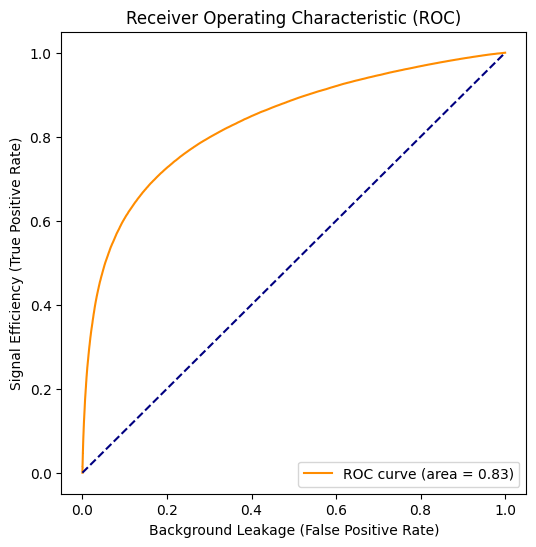

In [18]:
# Exercise 8
from sklearn.metrics import roc_curve, auc

# Calculating the curve points
fpr, tpr, _ = roc_curve(df['signal'], df['Fisher'])
roc_auc = auc(fpr, tpr)

# Plotting result
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # The "Random Guess" line
plt.xlabel('Background Leakage (False Positive Rate)')
plt.ylabel('Signal Efficiency (True Positive Rate)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()
